# MAB Simulation — ε-Greedy · UCB1 · Thompson Sampling

**Arms**: 5 discount levels applied to the listing's original price: −15%, −10%, 0%, +10%, +15%.  
**Reward**: predicted P(booked | adjusted price) × adjusted price (expected revenue per transaction).  

**Simulation design**:
- Each of the 30 rounds is **independent** — agent state resets at round start.  
- Within each round the agent runs 5 000 transactions, learning which discount maximises revenue.  
- The **within-round learning curve** (cumulative reward vs step, averaged across 30 rounds)  
  shows how fast each strategy converges to the best arm.  
- The **30 per-round totals** provide the sample for statistical testing against the baseline.

## 1. Imports & Configuration

In [283]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os, warnings
warnings.filterwarnings('ignore')

BASE_DIR   = os.path.dirname(os.getcwd())
DATA_PATH  = os.path.join(BASE_DIR, 'data',    'processed_data.csv')
MODEL_PATH = os.path.join(BASE_DIR, 'model',   'xgboost_model.pkl')
RESULT_DIR = os.path.join(BASE_DIR, 'results')
os.makedirs(RESULT_DIR, exist_ok=True)

N_ROUNDS       = 30
N_TRANSACTIONS = 50_000
SEED_BASE      = 42

ARM_DISCOUNTS  = np.array([0.90, 0.95, 1.00, 1.05, 1.10])
ARM_LABELS     = ['-10%', '-5%', '0%', '+5%', '+10%']
N_ARMS         = len(ARM_DISCOUNTS)
BASELINE_ARM   = 2

ARM_COLORS = ['#2166AC', '#74ADD1', '#888888', '#F46D43', '#D73027']
AGENT_COLORS = {
    'baseline':           '#888888',
    'epsilon_greedy':     '#E8762B',
    'ucb1':               '#1C8B5A',
    'thompson_sampling':  '#9B59B6',
}

# ── α-β scalarized occupancy constraint ────────────────────────────────────
# Normalized reward = α × (GMV / GMV_mean)  +  (1−α) × (−shortfall / τ)
# Both terms are dimensionless:
#   GMV / GMV_mean  ≈ 1.0 on average  (>1 for high-GMV listings)
#   shortfall / τ   ∈ [0, 1]          (1 = max violation, 0 = fully satisfied)
# α=1 → pure GMV; α=0 → pure occupancy protection; α=0.7 → 70/30 split
#
# Ref: Pacchiano et al. (2021) "Stochastic Bandits with Linear Constraints" AISTATS
VOLUME_THRESHOLD = 0.95   # τ
ALPHA            = 0.50   # weight on GMV; (1−ALPHA) = weight on occupancy

print(f'Arms: {dict(zip(ARM_LABELS, ARM_DISCOUNTS))}')
print(f'N_ROUNDS={N_ROUNDS}  N_TRANSACTIONS={N_TRANSACTIONS:,}')
print(f'α-β constraint: α={ALPHA} (GMV)  β={1-ALPHA:.2f} (occupancy)  τ={VOLUME_THRESHOLD:.0%}')

Arms: {'-10%': np.float64(0.9), '-5%': np.float64(0.95), '0%': np.float64(1.0), '+5%': np.float64(1.05), '+10%': np.float64(1.1)}
N_ROUNDS=30  N_TRANSACTIONS=50,000
α-β constraint: α=0.5 (GMV)  β=0.50 (occupancy)  τ=95%


## 2. Load Model & Precompute Arm Rewards

In [284]:
saved    = joblib.load(MODEL_PATH)
model    = saved['model']
features = saved['features']

df = pd.read_csv(DATA_PATH, low_memory=False)
df = df.dropna(subset=['price_tier', 'price_listing']).copy()
df['price_tier'] = df['price_tier'].astype(int)
n_rows = len(df)
print(f'Data loaded: {df.shape}  n_rows={n_rows:,}')


def compute_tier(prices):
    t = np.zeros(len(prices), dtype=int)
    t[(prices > 100) & (prices <= 300)] = 1
    t[(prices > 300) & (prices <= 600)] = 2
    t[prices > 600] = 3
    return t


# ── Step 1: raw GMV rewards ──────────────────────────────────────────────────
print('\nPre-computing raw GMV rewards...')
arm_rewards_raw = np.zeros((N_ARMS, n_rows))
arm_probs       = np.zeros((N_ARMS, n_rows))

for a, discount in enumerate(ARM_DISCOUNTS):
    df_mod = df[features].copy()
    new_prices = df['price_listing'].values * discount
    if 'price_listing' in features:
        df_mod['price_listing'] = new_prices
    probs = model.predict_proba(df_mod)[:, 1]
    arm_rewards_raw[a] = probs * new_prices
    arm_probs[a]       = probs
    print(f'  Arm {a} ({ARM_LABELS[a]:>4s}, x{discount})  '
          f'mean_P={probs.mean():.4f}  mean_GMV={arm_rewards_raw[a].mean():.2f}')

print('Best arm (unconstrained):', ARM_LABELS[int(np.argmax(arm_rewards_raw.mean(axis=1)))])

# ── Step 2: normalization constants ─────────────────────────────────────────
# GMV_SCALE: normalize each arm's GMV to ~1.0 on average
# OCC_SCALE: normalize shortfall from [0, τ] → [0, 1]
GMV_SCALE = float(arm_rewards_raw.mean())   # ≈ 90 SGD; makes GMV/GMV_SCALE ≈ 1
OCC_SCALE = VOLUME_THRESHOLD                # = 0.60; shortfall/OCC_SCALE ∈ [0,1]
print(f'\nNormalization: GMV_SCALE={GMV_SCALE:.2f} SGD  OCC_SCALE={OCC_SCALE:.2f}')
print(f'α={ALPHA}  β={1-ALPHA:.2f}')
print(f'reward = {ALPHA}×(GMV/{GMV_SCALE:.0f}) + {1-ALPHA:.2f}×(−shortfall/{OCC_SCALE})')

# ── Step 3: apply α-β normalized soft reward ────────────────────────────────
# reward(a,i) = α × GMV_norm(a,i)  −  (1−α) × shortfall_norm(a,i)
#
# GMV_norm    = GMV(a,i) / GMV_SCALE          ∈ (0, ~5]
# shortfall   = max(0, τ − p_a[i]/p_0[i])    ∈ [0, τ]
# shortfall_norm = shortfall / OCC_SCALE      ∈ [0, 1]
#
# Both terms dimensionless → α and (1−α) are true comparable weights.
baseline_probs = arm_probs[BASELINE_ARM]

arm_rewards = np.zeros((N_ARMS, n_rows))
print(f'\nBuilding normalized α-β rewards (τ={VOLUME_THRESHOLD:.0%})...')
for a in range(N_ARMS):
    occ_ratio        = arm_probs[a] / np.clip(baseline_probs, 1e-9, None)
    shortfall_norm   = np.maximum(0, VOLUME_THRESHOLD - occ_ratio) / OCC_SCALE
    gmv_norm         = arm_rewards_raw[a] / GMV_SCALE
    arm_rewards[a]   = ALPHA * gmv_norm - (1 - ALPHA) * shortfall_norm
    n_viol = int((occ_ratio < VOLUME_THRESHOLD).sum())
    print(f'  Arm {a} ({ARM_LABELS[a]:>4s}): {n_viol:>8,} below threshold  '
          f'({n_viol/n_rows*100:.1f}%)  '
          f'mean_reward={arm_rewards[a].mean():.4f}')

print('Best arm (after α-β constraint):', ARM_LABELS[int(np.argmax(arm_rewards.mean(axis=1)))])
print(f'\nReward scale: min={arm_rewards.min():.3f}  max={arm_rewards.max():.3f}  '
      f'mean={arm_rewards.mean():.3f}  std={arm_rewards.std():.3f}')


# ── Per-tier × per-arm stats ─────────────────────────────────────────────────
N_TIERS = 4
TIER_LABELS_VIZ = {0: 'Budget (≤$100)', 1: 'Standard ($101-300)',
                   2: 'Premium ($301-600)', 3: 'Luxury (>$600)'}
tier_vals = df['price_tier'].values
tier_arm_rows = []
for a, discount in enumerate(ARM_DISCOUNTS):
    adj_prices = df['price_listing'].values * discount
    for t in range(N_TIERS):
        mask = (tier_vals == t)
        tier_arm_rows.append({
            'arm': a, 'arm_label': ARM_LABELS[a],
            'tier': t, 'tier_label': TIER_LABELS_VIZ[t],
            'mean_prob':      float(arm_probs[a, mask].mean()),
            'mean_adj_price': float(adj_prices[mask].mean()),
            'mean_reward':    float(arm_rewards[a, mask].mean()),
            'n_listings':     int(mask.sum()),
        })
tier_arm_df = pd.DataFrame(tier_arm_rows)
tier_arm_df.to_csv(os.path.join(RESULT_DIR, 'tier_arm_stats.csv'), index=False)
print('\nSaved tier_arm_stats.csv')
print(tier_arm_df.pivot(index='tier_label', columns='arm_label', values='mean_prob').round(4))

# ── Stratified tier pools ────────────────────────────────────────────────────
tier_pool_indices = {t: np.where(tier_vals == t)[0] for t in range(N_TIERS)}
tier_props = {t: len(v) / n_rows for t, v in tier_pool_indices.items()}
tier_ns    = {t: int(np.floor(tier_props[t] * N_TRANSACTIONS)) for t in range(N_TIERS)}
tier_ns[max(tier_props, key=tier_props.get)] += N_TRANSACTIONS - sum(tier_ns.values())
print('\nTier sample counts per round:', {t: tier_ns[t] for t in range(N_TIERS)})


def sample_round_indices(round_idx):
    seed = SEED_BASE + round_idx
    idx_list = []
    for t in range(N_TIERS):
        rs   = np.random.RandomState(seed)
        pool = tier_pool_indices[t]
        idx_list.extend(pool[rs.choice(len(pool), size=tier_ns[t], replace=True)])
    idx_array = np.array(idx_list)
    np.random.RandomState(seed + 9999).shuffle(idx_array)
    return idx_array

Data loaded: (953380, 15)  n_rows=953,380

Pre-computing raw GMV rewards...
  Arm 0 (-10%, x0.9)  mean_P=0.3431  mean_GMV=83.10
  Arm 1 ( -5%, x0.95)  mean_P=0.3376  mean_GMV=86.80
  Arm 2 (  0%, x1.0)  mean_P=0.3342  mean_GMV=90.12
  Arm 3 ( +5%, x1.05)  mean_P=0.3339  mean_GMV=94.57
  Arm 4 (+10%, x1.1)  mean_P=0.3353  mean_GMV=99.18
Best arm (unconstrained): +10%

Normalization: GMV_SCALE=90.76 SGD  OCC_SCALE=0.95
α=0.5  β=0.50
reward = 0.5×(GMV/91) + 0.50×(−shortfall/0.95)

Building normalized α-β rewards (τ=95%)...
  Arm 0 (-10%):  380,723 below threshold  (39.9%)  mean_reward=0.4021
  Arm 1 ( -5%):  363,744 below threshold  (38.2%)  mean_reward=0.4317
  Arm 2 (  0%):        0 below threshold  (0.0%)  mean_reward=0.4965
  Arm 3 ( +5%):  333,542 below threshold  (35.0%)  mean_reward=0.4810
  Arm 4 (+10%):  370,488 below threshold  (38.9%)  mean_reward=0.4924
Best arm (after α-β constraint): 0%

Reward scale: min=-0.469  max=10.638  mean=0.461  std=0.726

Saved tier_arm_stats.csv
ar

## 3. MAB Agent Classes

In [285]:
class EpsilonGreedy:
    """Epsilon-greedy with exponential decay. reset() re-initialises for each round."""
    def __init__(self, n_arms=N_ARMS, epsilon=0.20, decay=0.999, eps_min=0.02):
        self.n_arms, self._eps0, self.decay, self.eps_min = n_arms, epsilon, decay, eps_min
        self.reset()

    def reset(self):
        self.epsilon = self._eps0
        self.Q = np.zeros(self.n_arms)
        self.N = np.zeros(self.n_arms)

    def select_arm(self):
        if np.random.rand() < self.epsilon:
            return int(np.random.randint(self.n_arms))
        return int(np.argmax(self.Q))

    def update(self, arm, reward):
        self.N[arm] += 1
        self.Q[arm] += (reward - self.Q[arm]) / self.N[arm]
        self.epsilon  = max(self.eps_min, self.epsilon * self.decay)

    def arm_values(self): return self.Q.copy()
    def name(self):       return 'epsilon_greedy'


class UCB1:
    """UCB1 (Auer et al. 2002).  Selects argmax Q(a) + c*sqrt(ln t / N(a)).
    reward_scale normalises GMV rewards to [0,1] so the confidence bound
    is properly calibrated relative to the reward range.
    """
    def __init__(self, n_arms=N_ARMS, c=2.0, reward_scale=1.0):
        self.n_arms, self.c = n_arms, c
        self.reward_scale = reward_scale   # e.g. arm_rewards.max()
        self.reset()

    def reset(self):
        self.Q = np.zeros(self.n_arms)   # stored in normalised [0,1] scale
        self.N = np.zeros(self.n_arms)
        self.t = 0

    def select_arm(self):
        unvisited = np.where(self.N == 0)[0]
        if len(unvisited):
            return int(unvisited[0])
        return int(np.argmax(self.Q + self.c * np.sqrt(np.log(self.t) / self.N)))

    def update(self, arm, reward):
        self.t += 1;  self.N[arm] += 1
        r_norm = reward / self.reward_scale          # normalise to [0,1]
        self.Q[arm] += (r_norm - self.Q[arm]) / self.N[arm]

    def arm_values(self): return self.Q * self.reward_scale  # back to GMV scale
    def name(self):       return 'ucb1'


class ThompsonSampling:
    """
    Gaussian Thompson Sampling.
    Samples theta_a ~ N(Q_a, (sigma / sqrt(N_a))^2) and picks argmax.
    sigma is set relative to expected reward scale (~100 SGD).
    """
    def __init__(self, n_arms=N_ARMS, sigma=50.0):
        self.n_arms, self.sigma = n_arms, sigma
        self.reset()

    def reset(self):
        self.Q = np.zeros(self.n_arms)
        self.N = np.zeros(self.n_arms)

    def select_arm(self):
        std     = self.sigma / np.sqrt(np.maximum(self.N, 1))
        samples = np.random.normal(self.Q, std)
        return int(np.argmax(samples))

    def update(self, arm, reward):
        self.N[arm] += 1
        self.Q[arm] += (reward - self.Q[arm]) / self.N[arm]

    def arm_values(self): return self.Q.copy()
    def name(self):       return 'thompson_sampling'

## 4. Simulation Loop

In [286]:
def run_simulation(agent, arm_rewards_learn, arm_rewards_report=None,
                   n_rounds=N_ROUNDS, n_transactions=N_TRANSACTIONS):
    """
    Run MAB simulation over n_rounds, each round independent (agent resets).

    Parameters
    ----------
    arm_rewards_learn  : (N_ARMS, n_rows) — what the agent learns from.
                         After α-β normalization: dimensionless, ~[-0.3, 3.5].
    arm_rewards_report : (N_ARMS, n_rows) — what gets recorded as total_reward
                         and within_cumulative. Defaults to arm_rewards_learn.
                         Pass arm_rewards_raw (SGD) to keep output comparable
                         with the baseline in 08_comparison.ipynb.

    Returns
    -------
    results_df        : DataFrame, one row per round (total_reward in report units)
    within_cumulative : (n_rounds, n_transactions) step-wise cumulative report reward
    arm_history       : (n_rounds, n_transactions, dtype=int8)
    """
    if arm_rewards_report is None:
        arm_rewards_report = arm_rewards_learn

    n_arms  = arm_rewards_learn.shape[0]
    records = []
    within_cumulative = np.zeros((n_rounds, n_transactions))
    arm_history       = np.zeros((n_rounds, n_transactions), dtype=np.int8)

    for r in range(n_rounds):
        agent.reset()
        round_indices = sample_round_indices(r)
        arm_counts    = np.zeros(n_arms, dtype=int)
        arm_totals    = np.zeros(n_arms)
        cumulative    = 0.0

        for step in range(n_transactions):
            arm     = agent.select_arm()
            idx     = int(round_indices[step])
            l_rew   = float(arm_rewards_learn[arm, idx])    # agent learns from this
            r_rew   = float(arm_rewards_report[arm, idx])   # reported as business metric
            agent.update(arm, l_rew)
            arm_counts[arm]  += 1
            arm_totals[arm]  += r_rew
            cumulative       += r_rew
            within_cumulative[r, step] = cumulative
            arm_history[r, step]       = arm

        rec = {'round': r + 1, 'total_reward': cumulative}
        for a in range(n_arms):
            rec[f'n_arm_{a}']      = int(arm_counts[a])
            rec[f'reward_arm_{a}'] = float(arm_totals[a])
            rec[f'Q_arm_{a}']      = float(agent.arm_values()[a])
        records.append(rec)

        q_str = '  '.join(f'Q{a}={agent.arm_values()[a]:.3f}' for a in range(n_arms))
        print(f'Round {r+1:2d}/{n_rounds}  '
              f'GMV={cumulative:>10,.0f}  '
              f'counts={arm_counts.tolist()}  {q_str}')

    return pd.DataFrame(records), within_cumulative, arm_history

In [287]:
all_results    = {}
all_within     = {}
all_arm_hist   = {}

# ── Load 05's baseline (stratified sampling, 0% discount) ──────────────────
baseline_csv = pd.read_csv(os.path.join(RESULT_DIR, 'baseline_results.csv'))
print(f'Baseline loaded from 05  |  mean GMV/round: {baseline_csv["total_reward"].mean():,.0f}')

# Baseline within-round curve uses RAW GMV (arm_rewards_raw) so axis stays in SGD
print('Computing baseline within-round curve...')
baseline_wc = np.zeros((N_ROUNDS, N_TRANSACTIONS))
for r in range(N_ROUNDS):
    round_indices = sample_round_indices(r)
    baseline_wc[r] = np.cumsum(arm_rewards_raw[BASELINE_ARM, round_indices])

all_results['baseline']  = baseline_csv[['round', 'total_reward']]
all_within['baseline']   = baseline_wc
all_arm_hist['baseline'] = np.full((N_ROUNDS, N_TRANSACTIONS), BASELINE_ARM, dtype=np.int8)

# ── TS sigma: calibrate to the normalized reward scale ─────────────────────
# arm_rewards std (normalized) ≈ 0.3–0.6 → sigma~0.3 gives meaningful exploration
ts_sigma = float(arm_rewards.std())
print(f'\nThompsonSampling sigma set to arm_rewards.std() = {ts_sigma:.4f}  '
      f'(was 50.0 for raw SGD scale)')

# ── Run MAB agents ──────────────────────────────────────────────────────────
# arm_rewards       → normalized α-β signal (agent learns)
# arm_rewards_raw   → raw GMV in SGD       (total_reward reported)
agent_defs = [
    ('epsilon_greedy',    EpsilonGreedy(),                                    SEED_BASE + 10),
    ('ucb1',              UCB1(reward_scale=float(arm_rewards.max())),         SEED_BASE + 20),
    ('thompson_sampling', ThompsonSampling(sigma=ts_sigma),                   SEED_BASE + 30),
]
for name, agent, seed in agent_defs:
    print(f'\n=== {name} ===')
    np.random.seed(seed)
    res, wc, ah = run_simulation(agent,
                                  arm_rewards_learn=arm_rewards,
                                  arm_rewards_report=arm_rewards_raw)
    all_results[name]  = res
    all_within[name]   = wc
    all_arm_hist[name] = ah

print('\nAll simulations complete.')

Baseline loaded from 05  |  mean GMV/round: 4,511,037
Computing baseline within-round curve...

ThompsonSampling sigma set to arm_rewards.std() = 0.7258  (was 50.0 for raw SGD scale)

=== epsilon_greedy ===
Round  1/30  GMV= 4,497,439  counts=[318, 229, 45824, 218, 3411]  Q0=0.459  Q1=0.407  Q2=0.493  Q3=0.426  Q4=0.487
Round  2/30  GMV= 4,729,178  counts=[454, 294, 514, 48507, 231]  Q0=0.382  Q1=0.429  Q2=0.454  Q3=0.483  Q4=0.360
Round  3/30  GMV= 4,984,977  counts=[227, 399, 416, 223, 48735]  Q0=0.344  Q1=0.442  Q2=0.492  Q3=0.486  Q4=0.497
Round  4/30  GMV= 4,935,167  counts=[230, 224, 223, 251, 49072]  Q0=0.355  Q1=0.448  Q2=0.451  Q3=0.424  Q4=0.491
Round  5/30  GMV= 4,485,968  counts=[311, 383, 47931, 231, 1144]  Q0=0.369  Q1=0.432  Q2=0.494  Q3=0.420  Q4=0.491
Round  6/30  GMV= 4,541,350  counts=[251, 230, 48188, 820, 511]  Q0=0.365  Q1=0.432  Q2=0.500  Q3=0.484  Q4=0.495
Round  7/30  GMV= 4,814,133  counts=[298, 236, 13011, 238, 36217]  Q0=0.389  Q1=0.422  Q2=0.503  Q3=0.485  

## 5. Results Summary

In [288]:
b_mean = all_results['baseline']['total_reward'].mean()
print(f'{"Strategy":<22} {"Mean/round":>12} {"Std":>9} {"vs Baseline":>13}')
print('-' * 60)
for name, df_r in all_results.items():
    mean = df_r['total_reward'].mean()
    std  = df_r['total_reward'].std()
    diff = f'{(mean - b_mean) / b_mean * 100:+.2f}%' if name != 'baseline' else '—'
    print(f'{name:<22} {mean:>12,.0f} {std:>9,.0f} {diff:>13}')

Strategy                 Mean/round       Std   vs Baseline
------------------------------------------------------------
baseline                  4,511,037    27,290             —
epsilon_greedy            4,725,412   190,961        +4.75%
ucb1                      4,566,352    24,415        +1.23%
thompson_sampling         4,689,164   111,751        +3.95%


## 6. Visualisation

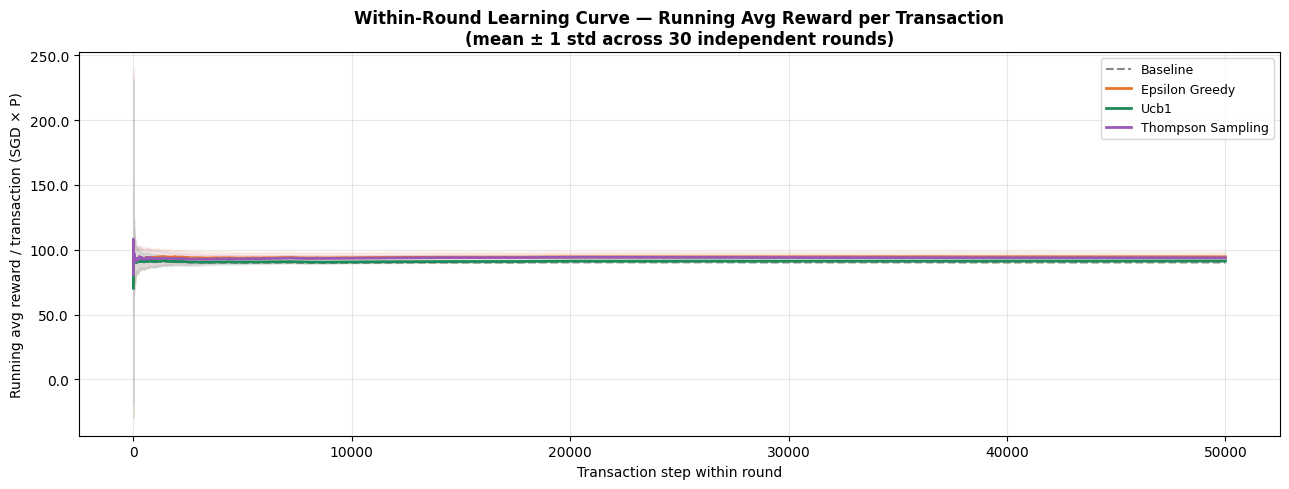

Upward slope = agent learning to pick higher-reward arms over the 5 000 steps.


In [289]:
# ── Within-round learning curve (main plot) ────────────────────────────
# Shows: given agent starts from zero, how fast does it converge to the best arm?
# Y-axis: running average reward per transaction  (cumulative / step)
# Each line = mean across 30 rounds; shaded band = ±1 std

steps = np.arange(1, N_TRANSACTIONS + 1)

fig, ax = plt.subplots(figsize=(13, 5))

for name, wc in all_within.items():
    # Convert cumulative reward to running average per transaction
    running_avg = wc / steps[np.newaxis, :]     # shape (n_rounds, n_transactions)
    mean_curve  = running_avg.mean(axis=0)
    std_curve   = running_avg.std(axis=0)
    color = AGENT_COLORS[name]
    ls    = '--' if name == 'baseline' else '-'
    lw    = 1.5  if name == 'baseline' else 2.0
    ax.plot(steps, mean_curve, color=color, linestyle=ls, linewidth=lw,
            label=name.replace('_', ' ').title())
    if name != 'baseline':
        ax.fill_between(steps, mean_curve - std_curve, mean_curve + std_curve,
                        color=color, alpha=0.10)

ax.set_title('Within-Round Learning Curve — Running Avg Reward per Transaction\n'
             '(mean ± 1 std across 30 independent rounds)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Transaction step within round')
ax.set_ylabel('Running avg reward / transaction (SGD × P)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}'))
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'mab_within_round_learning.png'), dpi=120)
plt.show()
print('Upward slope = agent learning to pick higher-reward arms over the 5 000 steps.')

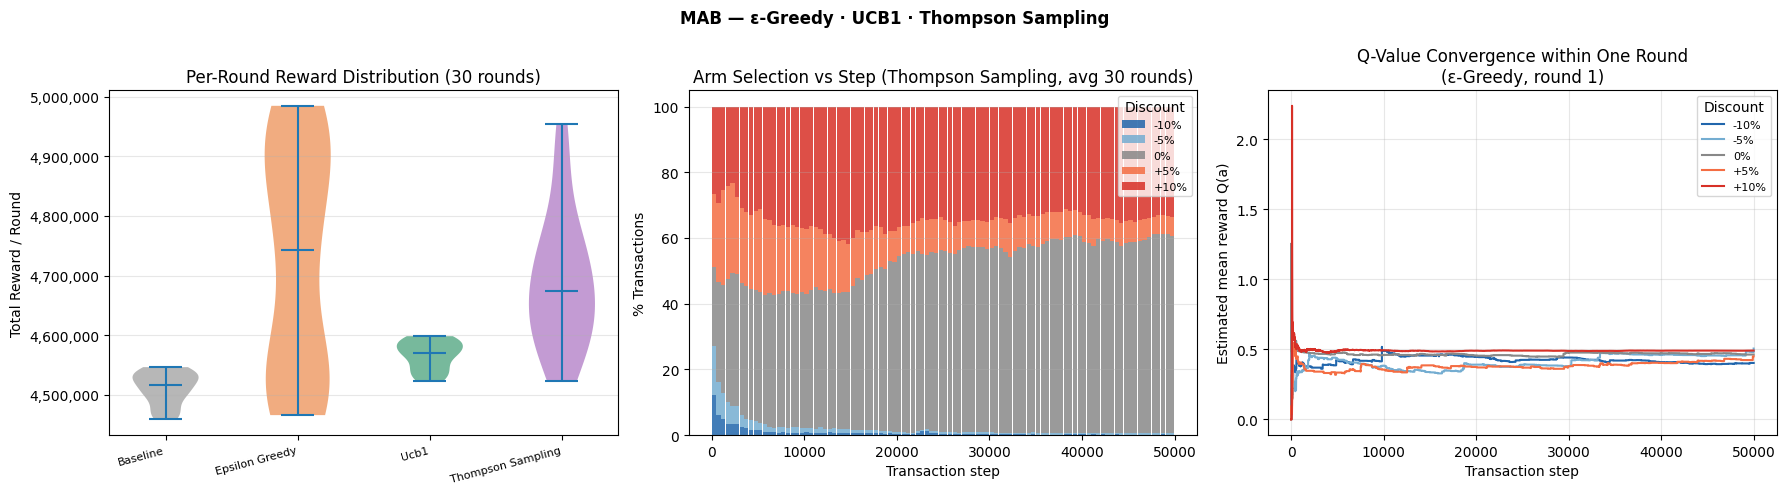

In [290]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('MAB — ε-Greedy · UCB1 · Thompson Sampling', fontsize=12, fontweight='bold')

# ── (1) Per-round total reward — 30 rounds distribution ───────────────
ax = axes[0]
names   = list(all_results.keys())
data    = [all_results[n]['total_reward'].values for n in names]
labels  = [n.replace('_', ' ').title() for n in names]
colors  = [AGENT_COLORS[n] for n in names]
vp = ax.violinplot(data, positions=range(len(names)), showmedians=True)
for body, color in zip(vp['bodies'], colors):
    body.set_facecolor(color);  body.set_alpha(0.6)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=8)
ax.set_title('Per-Round Reward Distribution (30 rounds)')
ax.set_ylabel('Total Reward / Round')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(alpha=0.3, axis='y')

# ── (2) Arm selection evolution within a round (avg across 30 rounds) ──
ax = axes[1]
# Use ε-Greedy as representative example; bin into 500-step windows
BIN = 500
n_bins  = N_TRANSACTIONS // BIN
bin_mids = (np.arange(n_bins) + 0.5) * BIN
ah_eg   = all_arm_hist['thompson_sampling']    # (n_rounds, n_transactions)
bottom  = np.zeros(n_bins)
for a in range(N_ARMS):
    prop = np.array([
        (ah_eg[:, b*BIN:(b+1)*BIN] == a).mean()
        for b in range(n_bins)
    ])
    ax.bar(bin_mids, prop * 100, bottom=bottom, width=BIN * 0.9,
           color=ARM_COLORS[a], label=ARM_LABELS[a], alpha=0.85)
    bottom += prop * 100
ax.set_title('Arm Selection vs Step (Thompson Sampling, avg 30 rounds)')
ax.set_xlabel('Transaction step')
ax.set_ylabel('% Transactions')
ax.legend(fontsize=8, title='Discount')
ax.grid(alpha=0.3, axis='y')

# ── (3) Q-value convergence within a round (ε-Greedy) ────────────────
# Re-run one round with Q recorded every step for illustration
ax = axes[2]
agent_demo = EpsilonGreedy()
agent_demo.reset()
rng_demo   = np.random.default_rng(SEED_BASE)
q_trace    = np.zeros((N_TRANSACTIONS, N_ARMS))
for step in range(N_TRANSACTIONS):
    arm    = agent_demo.select_arm()
    idx    = int(rng_demo.integers(n_rows))
    reward = float(arm_rewards[arm, idx])
    agent_demo.update(arm, reward)
    q_trace[step] = agent_demo.arm_values()
for a in range(N_ARMS):
    ax.plot(np.arange(1, N_TRANSACTIONS + 1), q_trace[:, a],
            color=ARM_COLORS[a], linewidth=1.5, label=ARM_LABELS[a])
ax.set_title('Q-Value Convergence within One Round\n(ε-Greedy, round 1)')
ax.set_xlabel('Transaction step')
ax.set_ylabel('Estimated mean reward Q(a)')
ax.legend(fontsize=8, title='Discount')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'mab_analysis.png'), dpi=120)
plt.show()

## 7. Save Results

In [291]:
# Save baseline_within_round for use by 07_linucb.ipynb
np.save(os.path.join(RESULT_DIR, 'baseline_within_round.npy'), baseline_wc)
print(f'Saved within: {os.path.join(RESULT_DIR, "baseline_within_round.npy")}')

# Save MAB agent results only (baseline_results.csv is owned by 05_baseline.ipynb)
for name, df_r in all_results.items():
    if name == 'baseline':
        continue
    path = os.path.join(RESULT_DIR, f'{name}_results.csv')
    df_r.to_csv(path, index=False)
    print(f'Saved results:  {path}')

for name, wc in all_within.items():
    if name == 'baseline':
        continue
    path = os.path.join(RESULT_DIR, f'{name}_within_round.npy')
    np.save(path, wc)
    print(f'Saved within:   {path}')

# Save arm history for tier-level analysis in 08_comparison.ipynb
for name, ah in all_arm_hist.items():
    if name == 'baseline':
        continue
    path = os.path.join(RESULT_DIR, f'{name}_arm_history.npy')
    np.save(path, ah)
    print(f'Saved arm_hist: {path}')

Saved within: d:\School\msba\作业\5113\group\sg\results\baseline_within_round.npy
Saved results:  d:\School\msba\作业\5113\group\sg\results\epsilon_greedy_results.csv
Saved results:  d:\School\msba\作业\5113\group\sg\results\ucb1_results.csv
Saved results:  d:\School\msba\作业\5113\group\sg\results\thompson_sampling_results.csv
Saved within:   d:\School\msba\作业\5113\group\sg\results\epsilon_greedy_within_round.npy
Saved within:   d:\School\msba\作业\5113\group\sg\results\ucb1_within_round.npy
Saved within:   d:\School\msba\作业\5113\group\sg\results\thompson_sampling_within_round.npy
Saved arm_hist: d:\School\msba\作业\5113\group\sg\results\epsilon_greedy_arm_history.npy
Saved arm_hist: d:\School\msba\作业\5113\group\sg\results\ucb1_arm_history.npy
Saved arm_hist: d:\School\msba\作业\5113\group\sg\results\thompson_sampling_arm_history.npy
